# Day 1 模块 6：第一天图表与复盘

这一模块的重点：第一次把数字变成图。

前面我们已经算出了一些结果，但如果只看表格和数字，有时不够直观。

这时候就要继续问：

- 营收是怎么随时间变化的？
- 不同天气的平均营收谁更高？
- 能不能用一张图更快看出规律？

In [12]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

candidate_paths = [Path('day1_cafe_sales.csv'), Path('day1') / 'day1_cafe_sales.csv', Path('教学课程') / 'day1' / 'day1_cafe_sales.csv']
for path in candidate_paths:
    if path.exists():
        csv_path = path
        break
else:
    raise FileNotFoundError('未找到 day1_cafe_sales.csv')
df = pd.read_csv(csv_path)

weather_order = ['晴', '多云', '阴', '小雨', '大雨']  # 排序方法
avg_sales_by_weather = df.groupby('weather_label')['sales'].mean().reindex(weather_order).round(2)

avg_sales_by_weather1 = df.groupby('weather_label')['sales'].mean()
print(avg_sales_by_weather1)
print(avg_sales_by_weather1.index)

weather_label
多云    2828.883721
大雨    2345.625000
小雨    2439.695652
晴     2940.887500
阴     2623.052632
Name: sales, dtype: float64
Index(['多云', '大雨', '小雨', '晴', '阴'], dtype='object', name='weather_label')


## 1. 营收趋势折线图

现在我们先回答第一个问题：

> 这家店的营收每天是怎么变化的？

折线图适合看“变化过程”，所以这里先用折线图。

## 1.1 折线图和柱状图怎么选

先看图，先建立“看到问题就知道该选哪种图”的感觉。

![折线图和柱状图选择示意图](day1_line_vs_bar_chart_demo.png)

可以把选图理解成“问题决定工具”：

- 如果想看每天怎么变：优先想到折线图
- 如果想比不同类别谁更高：优先想到柱状图

所以图表不是为了好看，而是为了更快回答问题。

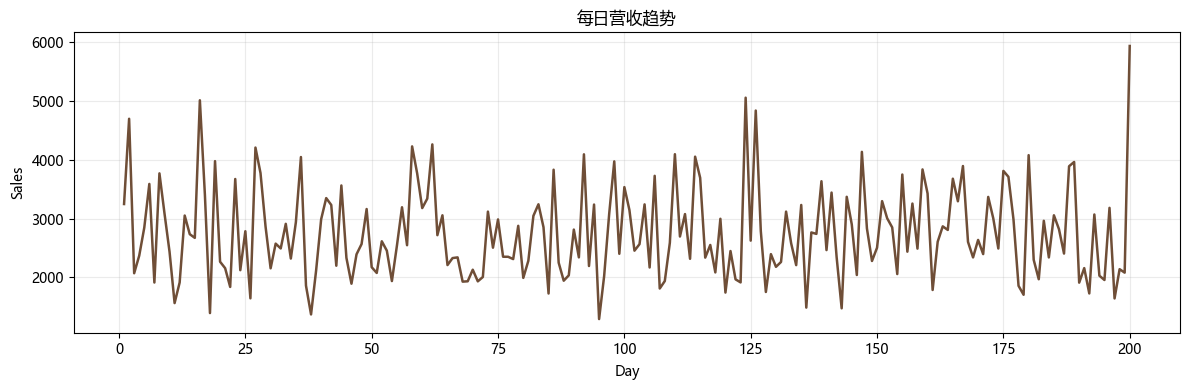

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(df['day'], df['sales'], color='#6f4e37', linewidth=1.8)
plt.title('每日营收趋势')
plt.xlabel('Day')
plt.ylabel('Sales')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 2. 天气分组柱状图

接着回答第二个问题：

> 不同天气下，平均营收谁更高？

柱状图适合比较不同类别，所以这里用柱状图来做对比。

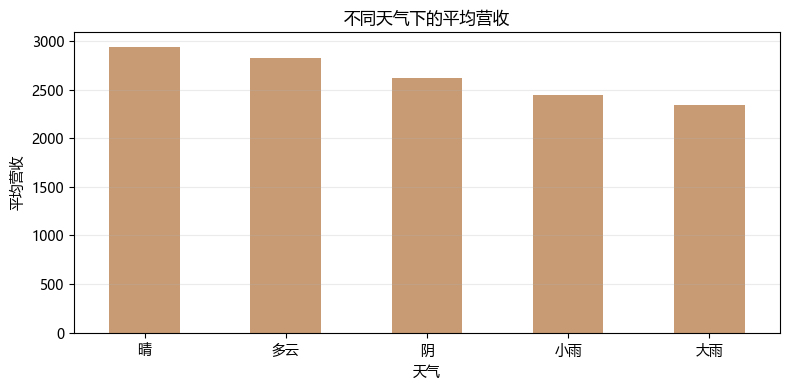

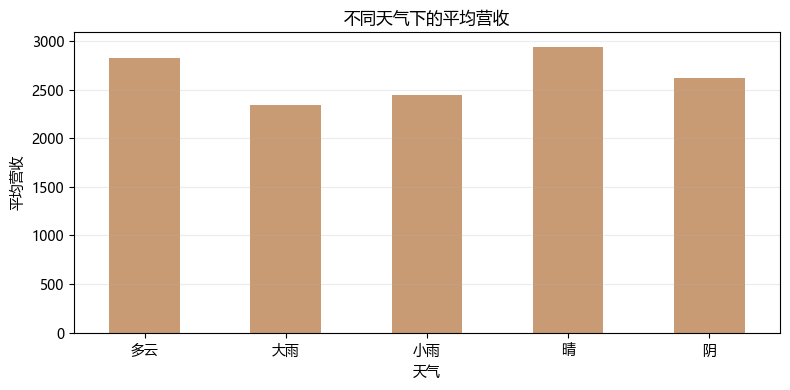

In [13]:
plt.figure(figsize=(8, 4))
avg_sales_by_weather.plot(kind='bar', color='#c89b74')
plt.title('不同天气下的平均营收')
plt.xlabel('天气')
plt.ylabel('平均营收')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
avg_sales_by_weather1.plot(kind='bar', color='#c89b74')
plt.title('不同天气下的平均营收')
plt.xlabel('天气')
plt.ylabel('平均营收')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


## 3. 看图说话

图表的目的不是好看，而是帮我们更快回答问题。

看图时，可以尝试用下面这几个问题来组织思路：

- 营收波动大不大？
- 哪种天气更容易带来高营收？
- 如果你是老板，你会根据这张图做什么判断？

最后尽量把结果说成一句完整的话，而不是只读数字。

In [8]:
best_weather = avg_sales_by_weather.idxmax()
best_value = avg_sales_by_weather.max()
print(f'平均营收最高的天气: {best_weather}，约为 {best_value:.2f} 元。')

平均营收最高的天气: 晴，约为 2940.89 元。


## 4. Day 1 复盘

今天我们已经走完了一条完整的小分析流程：

1. 先认识数据表
2. 学会最基础的 Python 语法
3. 用 `pandas` 读 CSV
4. 看懂行、列、字段、数据类型
5. 提出业务问题并做基础统计、分组分析
6. 用图把结果表达出来

这就完成了完整的 Day 1：

> 提出问题 → 分析问题 → 用数字和图回答问题